# Loading & Exploring sEMG Data

In [1]:
# need this to load .mat files
import scipy.io

In [2]:
# Step 1: Load EMG_S.mat

# This is the path to the data file
file_path = "../data/raw/EMG_S.mat"

# loadmat() reads the .mat file and returns a Python dictionary
data = scipy.io.loadmat(file_path)

print("File loaded successfully")

File loaded successfully


In [3]:
# Step 2: Print the shape and keys of the data

# Each key is the name of a variable that was saved inside the original .mat file
print("Keys in the data:")
print(data.keys())

Keys in the data:
dict_keys(['__header__', '__version__', '__globals__', 'matriz_ventanas'])


In [4]:
# Step 3: Check the shape and type of each variable

# Loop through every key in the dictionary to look at what's inside
for key in data.keys():
    value = data[key]

    # scipy adds a few extra keys automatically (like "__header__")
    # these start with double underscores, so skip them since they
    # aren't actual data
    if key.startswith("__"):
        continue

    print("Key:", key)
    print("Shape:", value.shape)
    print("Data type:", value.dtype)
    print("---")

Key: matriz_ventanas
Shape: (174000, 3, 200)
Data type: float64
---


In [5]:
# Step 4: Print the metadata keys, just to see what they contain

print("Header info:", data["__header__"])
print("Version:", data["__version__"])
print("Globals:", data["__globals__"])

Header info: b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Sat Nov 23 10:47:34 2024'
Version: 1.0
Globals: []


In [6]:
# just printing a few rows here, there's thousands so no point printing them all
# change the 5 in value[:5] below to see more or less
for key in data.keys():
    if key.startswith("__"):
        continue

    value = data[key]

    print("Key:", key)
    print("First few values:")
    print(value[:5])
    print("===")

Key: matriz_ventanas
First few values:
[[[-0.04006155 -0.00232896 -0.02167901 ... -0.02232401 -0.00136146
   -0.01619649]
  [-0.00458646 -0.00136146 -0.02716152 ...  0.04120865  0.25180167
    0.27760173]
  [-0.02425901  0.11248133  0.08668126 ...  0.24115914  0.19084902
   -0.10681922]]

 [[-0.0613466  -0.07102163 -0.1000467  ... -0.02812902 -0.02619402
   -0.02329151]
  [ 0.10603131  0.01798859 -0.1019817  ...  0.11635134  0.35983944
    0.13441138]
  [ 0.18633401  0.01669859 -0.04264156 ... -0.12842677  0.09151877
   -0.16132185]]

 [[ 0.00444356 -0.03490154  0.00379856 ... -0.11681674  0.00379856
   -0.03715904]
  [ 0.12441386  0.01863359 -0.12326676 ... -0.00458646 -0.03328903
    0.09764629]
  [ 0.00928107 -0.01684149 -0.19034692 ... -0.00781147  0.0618487
   -0.00974648]]

 [[-0.08263166 -0.01135898 -0.08972667 ...  0.03669364 -0.02845152
   -0.02200151]
  [-0.15035682 -0.16067685 -0.04070655 ... -0.0187765  -0.18776692
   -0.22904702]
  [-0.16164435  0.20826406  0.28695426 ... 

In [7]:
# "matriz_ventanas" is the real data - the EMG signal split into 
# small time windows. Saving it to its own variable so it's easier 
# to use later
matriz_ventanas = data['matriz_ventanas']

print("Extracted matriz_ventanas, shape:", matriz_ventanas.shape)

Extracted matriz_ventanas, shape: (174000, 3, 200)


# Phase 2: Gesture Labels

In [8]:
# Step 1: Load Labels.mat
# This file holds the gesture label for each window in matriz_ventanas

labels_path = "../data/raw/Labels.mat"
labels_data = scipy.io.loadmat(labels_path)

# Print the keys, same as before with the EMG data file
print("Keys in Labels.mat:")
print(labels_data.keys())
print()

# Print the shape of each real variable (skip the __ metadata keys)
for key in labels_data.keys():
    if key.startswith("__"):
        continue

    value = labels_data[key]
    print("Key:", key)
    print("Shape:", value.shape)
    print("Data type:", value.dtype)
    print("---")
print()

# Print a small preview of each variable
for key in labels_data.keys():
    if key.startswith("__"):
        continue

    value = labels_data[key]
    print("Key:", key)
    print("First 20 values:")
    print(value[:20])
    print("===")

Keys in Labels.mat:
dict_keys(['__header__', '__version__', '__globals__', 'labels'])

Key: labels
Shape: (174000, 5)
Data type: uint8
---

Key: labels
First 20 values:
[[1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]]
===


In [9]:
# Step 2: Check how many samples belong to each gesture

labels = labels_data["labels"]

# labels are one-hot encoded, meaning each row has one 1 (for its gesture)
# and the rest are 0, so adding up each column tells us how many samples
# belong to that gesture
counts_per_column = labels.sum(axis=0)

print("Sample count per column:")
for col_index, count in enumerate(counts_per_column):
    print(f"Column {col_index}: {count} samples")
print()

# Print the first 10 rows to see what the one-hot pattern actually looks like
print("First 10 rows of labels:")
print(labels[:10])

Sample count per column:
Column 0: 34800 samples
Column 1: 34800 samples
Column 2: 34800 samples
Column 3: 34800 samples
Column 4: 34800 samples

First 10 rows of labels:
[[1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]]


**Assumed gesture order** (based on the DS1 docs, haven't double checked this against the raw data yet):

- Column 0 = Gesture 1 (fist)
- Column 1 = Gesture 2 (thumb bend)
- Column 2 = Gesture 3 (rest)
- Column 3 = Gesture 4 (finger extension)
- Column 4 = Gesture 5 (middle/ring bend)

# Phase 3: Visualize Raw Signals

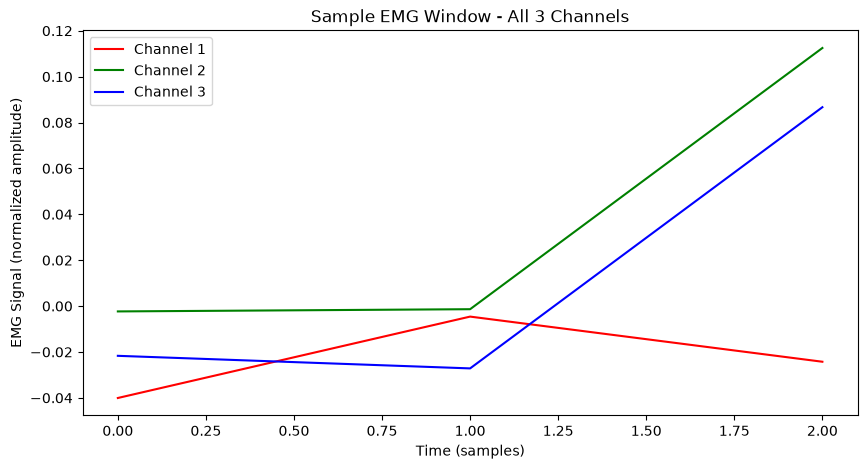

In [10]:
# using matplotlib to make the plots, it's simple and works fine for basic line plots
import matplotlib.pyplot as plt

# Step 1: Grab the first window from the windows matrix
# matriz_ventanas holds many windows, so [0] picks the very first one
first_window = matriz_ventanas[0]

# This window has 3 channels, one for each EMG sensor
# Pull each channel out as its own column of numbers
channel_1 = first_window[:, 0]
channel_2 = first_window[:, 1]
channel_3 = first_window[:, 2]

# Step 2: Create the plot and draw each channel in a different color
plt.figure(figsize=(10, 5))
plt.plot(channel_1, color="red", label="Channel 1")
plt.plot(channel_2, color="green", label="Channel 2")
plt.plot(channel_3, color="blue", label="Channel 3")

# Step 3: Label the axes
plt.xlabel("Time (samples)")
plt.ylabel("EMG Signal (normalized amplitude)")

# Step 4: Add a title
plt.title("Sample EMG Window - All 3 Channels")

# Show the legend so it's clear which color goes with which channel
plt.legend()

# Save a copy of this plot to the visualizations folder
plt.savefig('../visualizations/phase3_single_window.png', dpi=150, bbox_inches='tight')

# Display the plot
plt.show()

# Phase 4: Compare Signals Across Gestures

First window index for each gesture: [np.int64(0), np.int64(34800), np.int64(69600), np.int64(104400), np.int64(139200)]


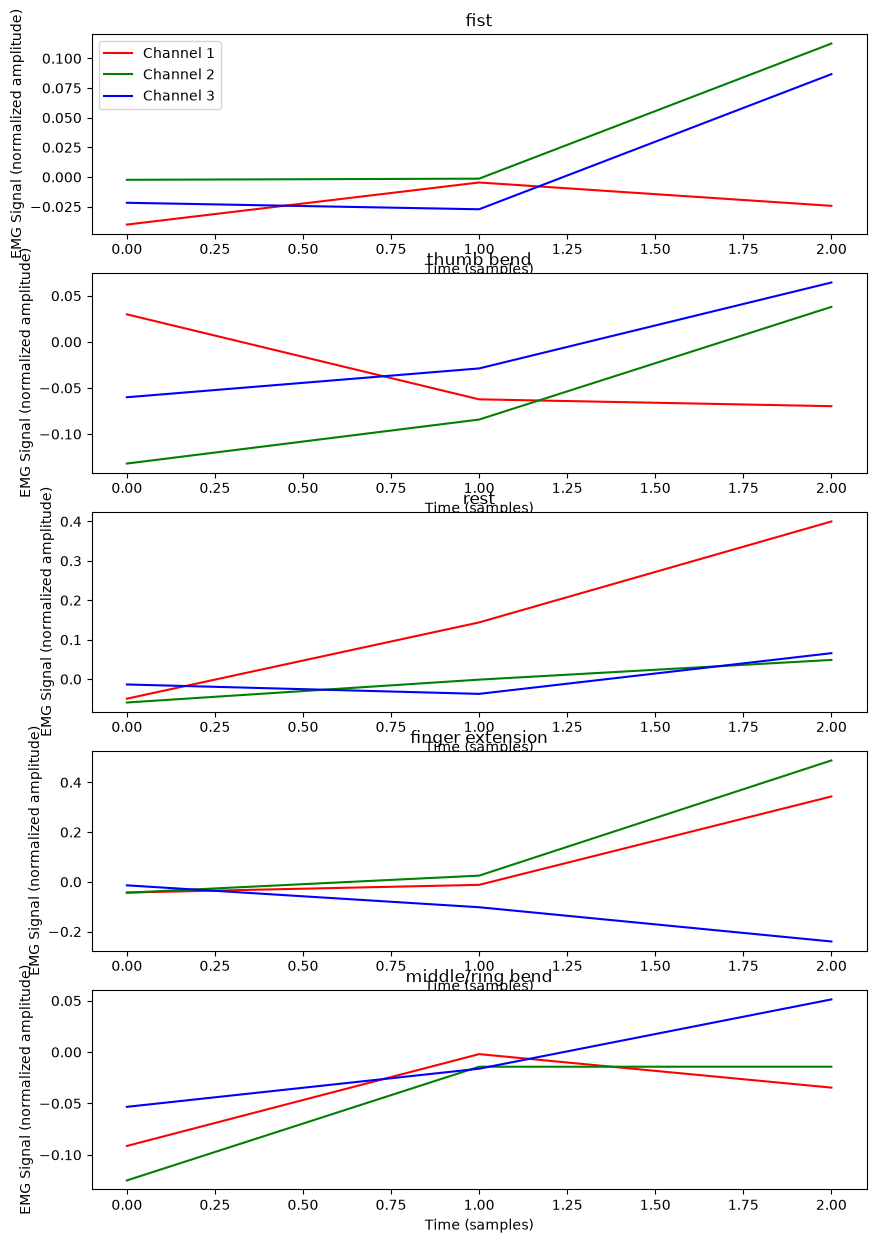

In [11]:
# Names of the 5 gestures, in the same column order as labels
gesture_names = [
    "fist",
    "thumb bend",
    "rest",
    "finger extension",
    "middle/ring bend",
]

# numpy's "where" function is needed to search the labels array
import numpy as np

# find the first window index for each gesture
# labels[:, gesture_index] is 0s and 1s for that gesture, so np.where()
# finds all the rows that match, and [0] grabs the first one
first_index_per_gesture = []

for gesture_index in range(5):
    matching_rows = np.where(labels[:, gesture_index] == 1)[0]
    first_index = matching_rows[0]
    first_index_per_gesture.append(first_index)

print("First window index for each gesture:", first_index_per_gesture)

# Create a figure with 5 subplots
fig, axes = plt.subplots(5, 1, figsize=(10, 15))

# Plot each gesture's example window in its own subplot
for gesture_index in range(5):
    window_index = first_index_per_gesture[gesture_index]
    example_window = matriz_ventanas[window_index]

    channel_1 = example_window[:, 0]
    channel_2 = example_window[:, 1]
    channel_3 = example_window[:, 2]

    ax = axes[gesture_index]
    ax.plot(channel_1, color="red", label="Channel 1")
    ax.plot(channel_2, color="green", label="Channel 2")
    ax.plot(channel_3, color="blue", label="Channel 3")

    ax.set_title(gesture_names[gesture_index])
    ax.set_xlabel("Time (samples)")
    ax.set_ylabel("EMG Signal (normalized amplitude)")

# Add a legend only to the top subplot, to avoid repeating it 5 times
axes[0].legend()

# Save a copy of this plot to the visualizations folder
plt.savefig('../visualizations/phase4_gesture_comparison.png', dpi=150, bbox_inches='tight')

plt.show()

# Phase 5: Basic Data Cleaning

In [12]:
# Check for missing values
nan_count = np.isnan(matriz_ventanas).sum()
print("Missing values:", nan_count)

# Check for windows that are all zeros
flat_count = 0
for window in matriz_ventanas:
    if np.all(window == 0):
        flat_count += 1
print("Flat windows:", flat_count)

# Check the range of values
print("Min:", matriz_ventanas.min())
print("Max:", matriz_ventanas.max())

if nan_count == 0 and flat_count == 0:
    print("Data is clean!", matriz_ventanas.shape[0])
else:
    print("No problems, data is already clean.")

Missing values: 0


Flat windows: 0
Min: -5.04559641747619
Max: 4.002808437100612
Data is clean! 174000


In [13]:
# Phase 6: Get the data ready for a classifier

# turn each window into 3 numbers, the average strength per channel
# matriz_ventanas is (windows, channels, time), so axis=2 is time
# averaging over axis=2 gives one number per channel instead of 200
features = np.mean(np.abs(matriz_ventanas), axis=2)

# turn the one-hot labels into a single gesture number (0 to 4)
gesture_number = np.argmax(labels, axis=1)

print("Features shape:", features.shape)

Features shape: (174000, 3)


In [14]:
# Train a simple classifier and check its accuracy

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    features, gesture_number, test_size=0.2, shuffle=True, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.6271551724137931
